# Python EDA + Business Insights

In [18]:
cd F:Downloads

[WinError 2] The system cannot find the file specified: 'F:Downloads'
F:\Downloads


# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Load Datasets

In [8]:
companies = pd.read_csv("projectflow-analytics/data/raw/companies.csv")

users = pd.read_csv("projectflow-analytics/data/raw/users.csv")

projects = pd.read_csv("projectflow-analytics/data/raw/projects.csv")

tasks = pd.read_csv("projectflow-analytics/data/raw/tasks.csv")

comments = pd.read_csv("projectflow-analytics/data/raw/comments.csv")

subscription = pd.read_csv(
    "projectflow-analytics/data/raw/subscription_history.csv"
)

activity = pd.read_csv(
    "projectflow-analytics/data/raw/activity_logs.csv"
)

# Verify Loading

In [9]:
datasets = {
    "companies": companies,
    "users": users,
    "projects": projects,
    "tasks": tasks,
    "comments": comments,
    "subscription": subscription,
    "activity": activity
}


for name, df in datasets.items():

    print(
        name,
        df.shape
    )

companies (10, 9)
users (444, 9)
projects (99, 9)
tasks (2520, 10)
comments (6346, 5)
subscription (15, 7)
activity (52822, 4)


# Data Quality Check

# Missing Values Check

In [17]:
for name, df in datasets.items():

    print("\n", name)

    print(
        df.isnull().sum()
    )


 companies
company_id           0
company_code         0
company_name         0
industry             0
city                 0
state                0
employee_count       0
registration_date    0
company_status       0
dtype: int64

 users
user_id        0
user_code      0
company_id     0
full_name      0
email          0
role           0
join_date      0
last_login     0
user_status    0
dtype: int64

 projects
project_id        0
project_code      0
company_id        0
created_by        0
project_name      0
project_status    0
priority          0
start_date        0
due_date          0
dtype: int64

 tasks
task_id                0
task_code              0
project_id             0
assigned_user_id       0
task_name              0
task_status            0
priority               0
created_date           0
due_date               0
completed_date      1512
dtype: int64

 comments
comment_id      0
task_id         0
user_id         0
comment_text    0
commented_at    0
dtype: int64

 sub

# Duplicate Check

In [11]:
for name, df in datasets.items():

    print(
        name,
        "duplicates:",
        df.duplicated().sum()
    )

companies duplicates: 0
users duplicates: 0
projects duplicates: 0
tasks duplicates: 0
comments duplicates: 0
subscription duplicates: 0
activity duplicates: 0


# Basic SaaS KPIs

In [12]:
total_companies = companies.shape[0]
total_users = users.shape[0]
total_projects = projects.shape[0]
total_tasks = tasks.shape[0]

print("Total Companies:", total_companies)
print("Total Users:", total_users)
print("Total Projects:", total_projects)
print("Total Tasks:", total_tasks)

Total Companies: 10
Total Users: 444
Total Projects: 99
Total Tasks: 2520


# User Analytics EDA

# Active vs Inactive Users

In [13]:
user_status_count = users[
    "user_status"
].value_counts()


user_status_count

user_status
Active      426
Inactive     18
Name: count, dtype: int64

# User Status Chart

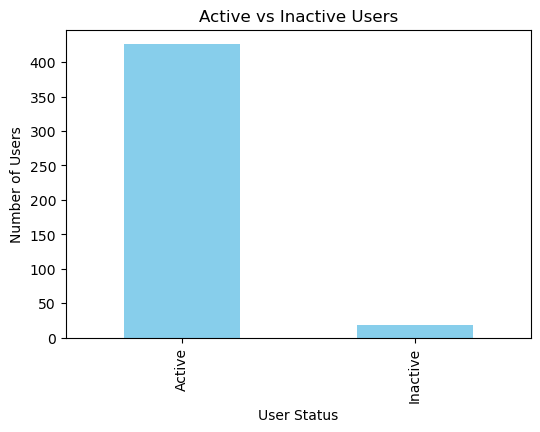

In [36]:
plt.figure(figsize=(6,4))
user_status_count.plot(kind="bar", color = "skyblue")
plt.title("Active vs Inactive Users")
plt.xlabel("User Status")
plt.ylabel("Number of Users")

plt.show()

# User Role Distribution

In [15]:
role_distribution = users[
    "role"
].value_counts()


role_distribution

role
Developer          275
Designer            66
Project Manager     47
QA                  45
Owner               11
Name: count, dtype: int64

# Role Distribution Chart

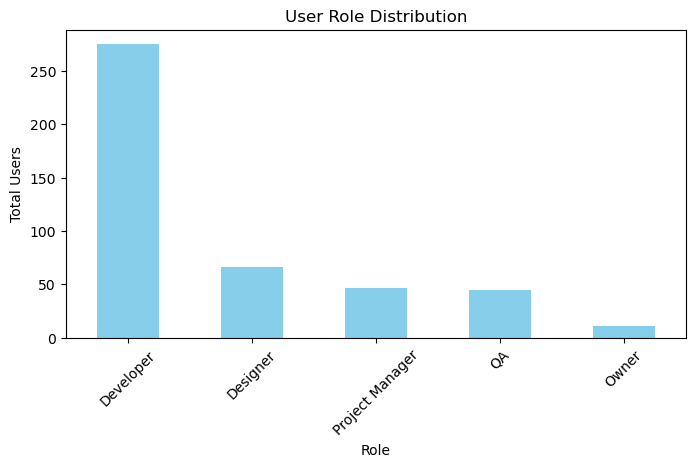

In [35]:
plt.figure(figsize=(8,4))
role_distribution.plot(kind="bar", color = "skyblue")
plt.title("User Role Distribution")
plt.xlabel("Role")
plt.ylabel("Total Users")
plt.xticks(rotation=45)

plt.show()

# DAU + MAU Analysis

# Convert Activity Date

In [21]:
activity["activity_time"] = pd.to_datetime(activity["activity_time"])
activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52822 entries, 0 to 52821
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   activity_id    52822 non-null  int64         
 1   user_id        52822 non-null  int64         
 2   activity_type  52822 non-null  object        
 3   activity_time  52822 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 1.6+ MB


# Daily Active Users (DAU)

In [22]:
dau = (activity[activity["activity_type"] == "login"].groupby(activity["activity_time"].dt.date)["user_id"].nunique())

dau.head()

activity_time
2026-01-01    103
2026-01-02     85
2026-01-03    112
2026-01-04     86
2026-01-05     83
Name: user_id, dtype: int64

# DAU Trend Chart

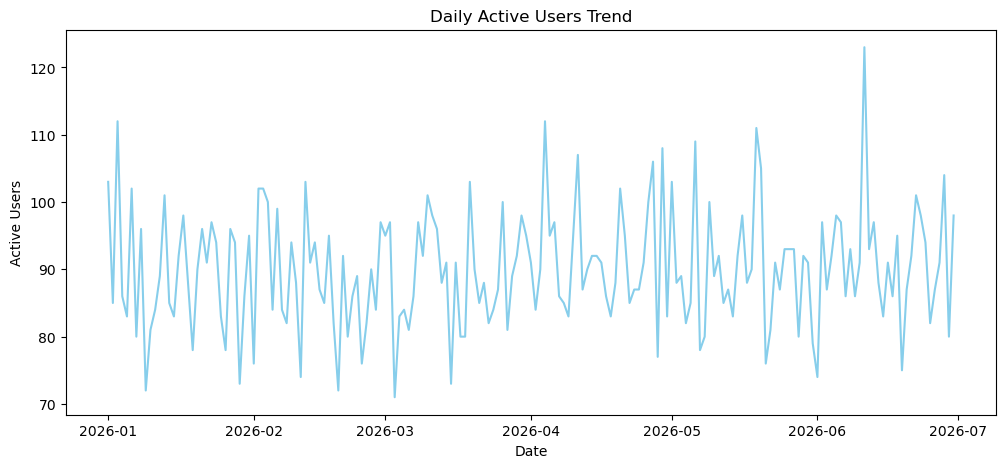

In [34]:
plt.figure(figsize=(12,5))
dau.plot(kind="line", color = "skyblue")
plt.title("Daily Active Users Trend")
plt.xlabel("Date")
plt.ylabel("Active Users")

plt.show()

# Monthly Active Users (MAU)

In [26]:
mau = (activity[activity["activity_type"] == "login"].groupby(activity["activity_time"].dt.month)["user_id"].nunique())

mau

activity_time
1    433
2    433
3    431
4    435
5    432
6    436
Name: user_id, dtype: int64

# MAU Chart

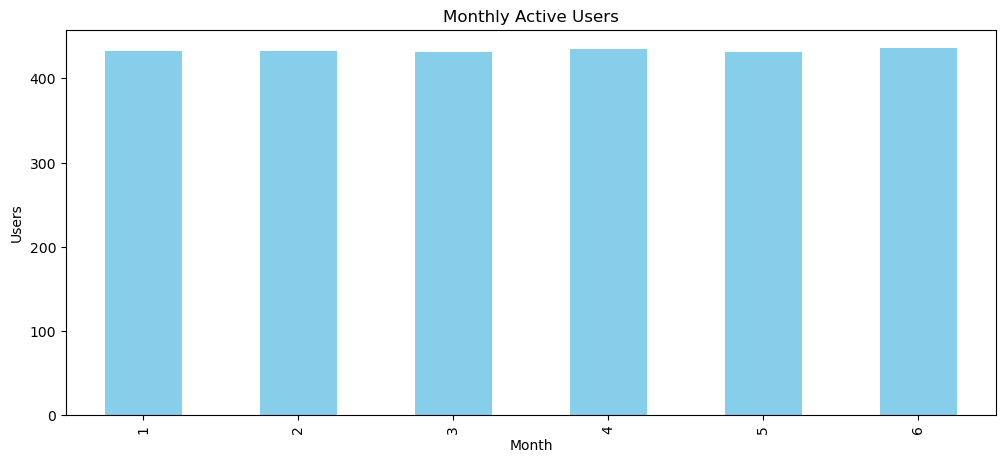

In [33]:
plt.figure(figsize=(12,5))
mau.plot(kind="bar", color = "skyblue")
plt.title("Monthly Active Users")
plt.xlabel("Month")
plt.ylabel("Users")

plt.show()

# Revenue Analysis

# Check Subscription Data

In [37]:
subscription.head()

,subscription_id,company_id,plan_name,monthly_price,start_date,end_date,subscription_status
0,1,1,pro,4999,2024-07-17,2025-02-17,expired
1,2,1,enterprise,19999,2025-02-17,NaN,active
2,3,2,free,0,2023-06-28,2024-07-01,expired
3,4,2,pro,4999,2024-07-01,NaN,active
4,5,3,free,0,2024-03-23,NaN,active


# Total MRR (Monthly Recurring Revenue)

In [41]:
active_subscription = subscription[subscription["subscription_status"] == "active"]

mrr = active_subscription["monthly_price"].sum()

print("Monthly Recurring Revenue:", mrr)

Monthly Recurring Revenue: 60993


# ARR (Annual Recurring Revenue)

In [42]:
arr = mrr * 12

print("Annual Recurring Revenue:",arr)

Annual Recurring Revenue: 731916


# Revenue By Plan

In [44]:
revenue_by_plan = (
    active_subscription
    .groupby("plan_name")
    ["monthly_price"]
    .sum()
    .sort_values(
        ascending=False
    )
)

revenue_by_plan

plan_name
enterprise    39998
pro           19996
starter         999
free              0
Name: monthly_price, dtype: int64

# Revenue By Plan Chart

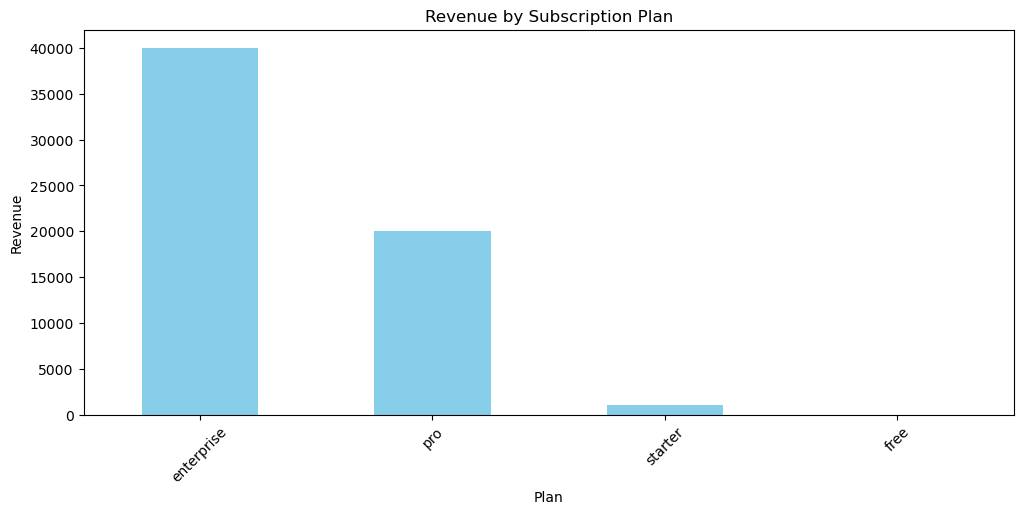

In [51]:
plt.figure(figsize=(12,5))
revenue_by_plan.plot(kind="bar", color = "skyblue")
plt.title("Revenue by Subscription Plan")
plt.xlabel("Plan")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

# Subscription Plan Distribution

In [47]:
plan_distribution = subscription["plan_name"].value_counts()

plan_distribution

plan_name
pro           6
free          5
enterprise    2
starter       2
Name: count, dtype: int64

# Plan Distribution Chart

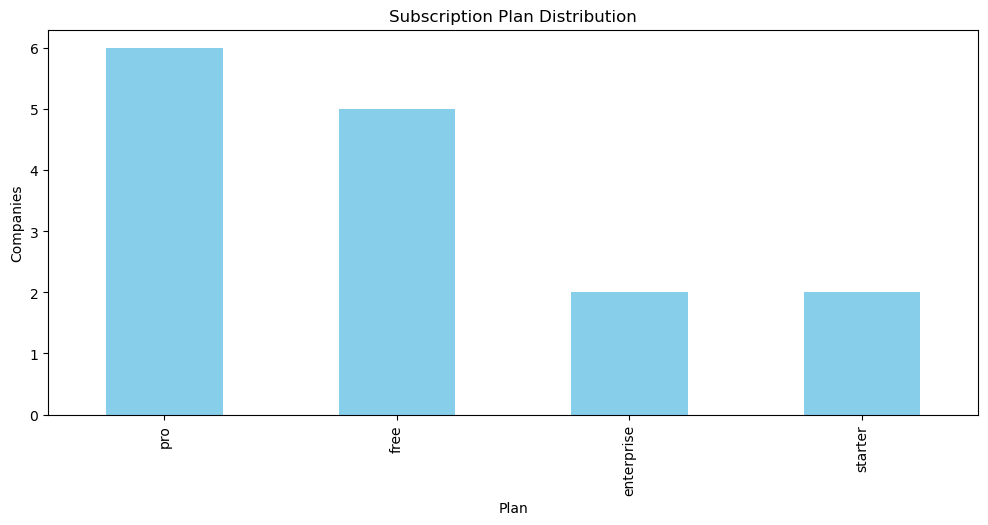

In [50]:
plt.figure(figsize=(12,5))
plan_distribution.plot(kind="bar", color = "skyblue")
plt.title("Subscription Plan Distribution")
plt.xlabel("Plan")
plt.ylabel("Companies")

plt.show()

# Project Performance EDA

# Task Status Analysis

In [53]:
task_status = tasks[
    "task_status"
].value_counts()

task_status

task_status
completed      1008
in progress     852
pending         660
Name: count, dtype: int64

# Task Status Chart

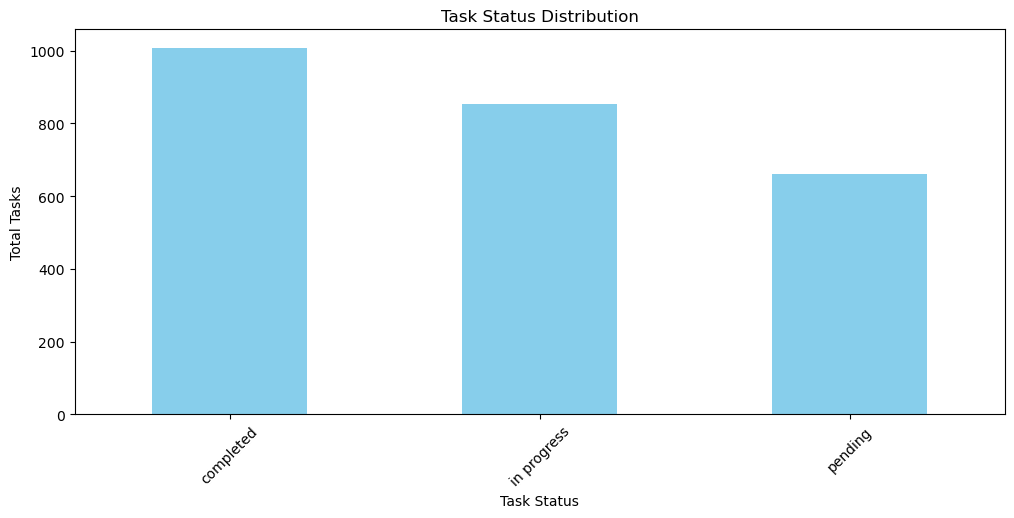

In [54]:
plt.figure(figsize=(12,5))
task_status.plot(kind="bar", color = "skyblue")
plt.title("Task Status Distribution")
plt.xlabel("Task Status")
plt.ylabel("Total Tasks")
plt.xticks(rotation=45)

plt.show()

# Project Completion %

In [57]:
project_completion = (
    tasks
    .groupby("project_id")
    .agg(
        total_tasks=("task_id","count"),

        completed_tasks=(
            "task_status",
            lambda x: (x=="completed").sum()
        )
    )
)
project_completion["completion_percentage"] = round((project_completion["completed_tasks"] / project_completion["total_tasks"]) * 100, 2)


project_completion.head()

,total_tasks,completed_tasks,completion_percentage
project_id,,,
1,30,13,43.33
2,34,6,17.65
3,21,9,42.86
4,38,18,47.37
5,22,7,31.82


# Average Completion Rate KPI

In [58]:
average_completion = (project_completion["completion_percentage"].mean())

print("Average Project Completion:",round(average_completion,2),"%")

Average Project Completion: 39.96 %


# Priority Analysis

In [59]:
priority_analysis = tasks["priority"].value_counts()

priority_analysis

priority
medium      1259
high         638
low          496
critical     127
Name: count, dtype: int64

# Priority Chart

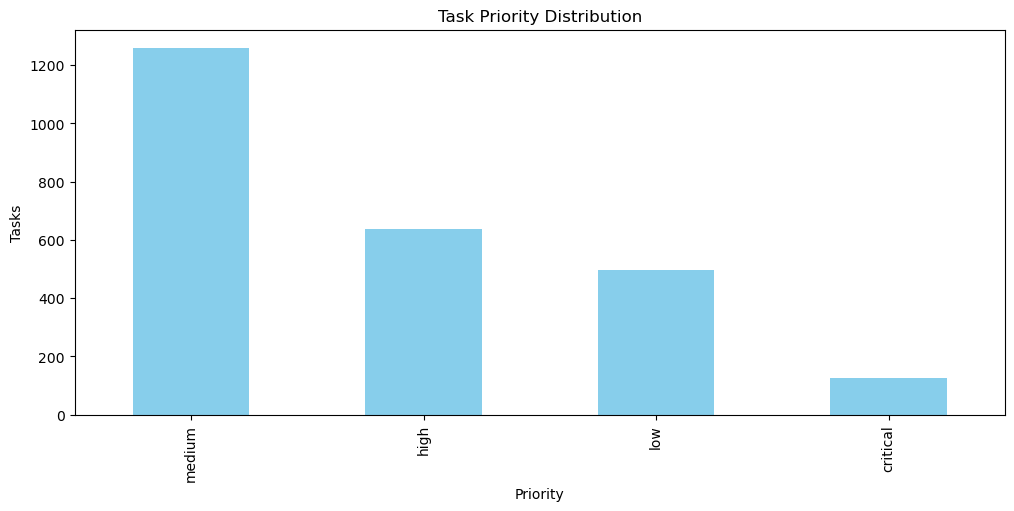

In [61]:
plt.figure(figsize=(12,5))
priority_analysis.plot(kind="bar", color = "skyblue")
plt.title("Task Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Tasks")

plt.show()

# Feature Usage + Engagement Analysis

# Feature Usage Count

In [63]:
feature_usage = activity["activity_type"].value_counts()

feature_usage

activity_type
login              18506
logout             10541
task_completed      7941
task_created        7879
comment_added       4225
project_created     2694
ai_used             1036
Name: count, dtype: int64

# Feature Usage Chart

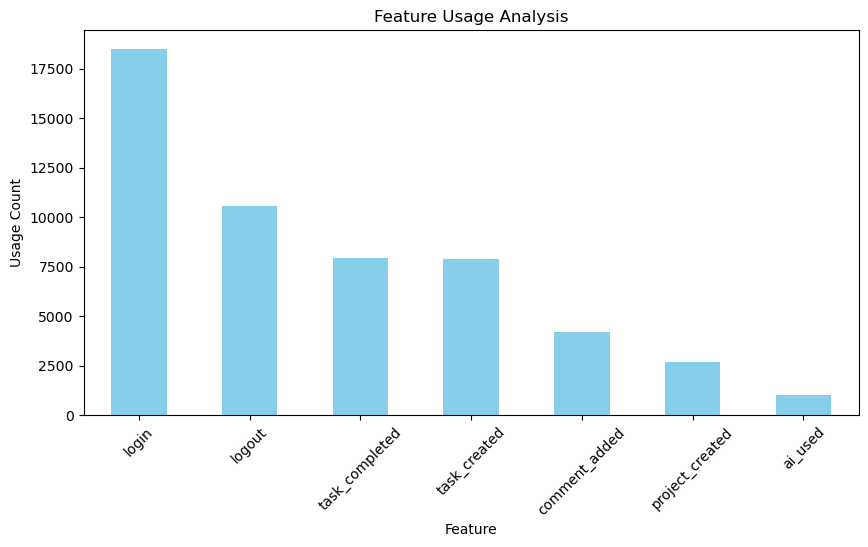

In [64]:
plt.figure(figsize=(10,5))
feature_usage.plot(kind="bar", color = "skyblue")
plt.title("Feature Usage Analysis")
plt.xlabel("Feature")
plt.ylabel("Usage Count")
plt.xticks(rotation=45)

plt.show()

# Top Active Users

In [66]:
top_users = (activity.groupby("user_id")["activity_id"].count().sort_values(ascending=False).head(10))

top_users

user_id
229    200
408    199
299    199
101    199
320    199
387    198
70     198
206    198
14     197
301    197
Name: activity_id, dtype: int64

# User Engagement Segmentation

In [68]:
user_activity = (activity.groupby("user_id")["activity_id"].count().reset_index())

user_activity.columns = ["user_id","total_activity"]

def engagement_level(activity):

    if activity >= 150:
        return "High Engagement"

    elif activity >= 50:
        return "Medium Engagement"

    else:
        return "Low Engagement"



user_activity["engagement_level"] = user_activity["total_activity"].apply(engagement_level)


user_activity.head()

,user_id,total_activity,engagement_level
0,1,78,Medium Engagement
1,2,64,Medium Engagement
2,3,68,Medium Engagement
3,4,185,High Engagement
4,5,166,High Engagement


# Engagement Distribution

In [69]:
engagement_distribution = user_activity["engagement_level"].value_counts()

engagement_distribution

engagement_level
Medium Engagement    291
High Engagement      135
Low Engagement        18
Name: count, dtype: int64

# Engagement Chart

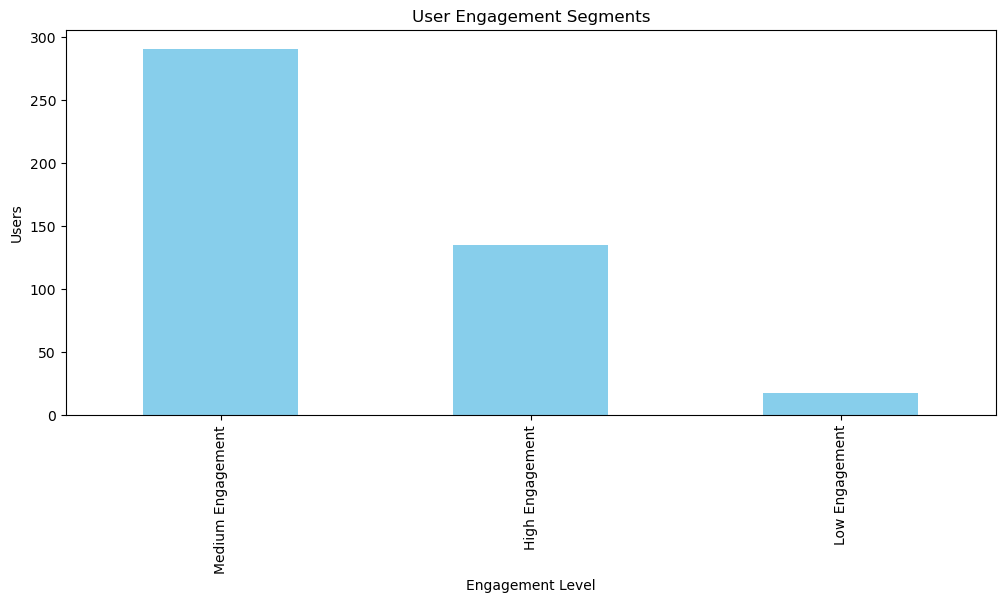

In [70]:
plt.figure(figsize=(12,5))
engagement_distribution.plot(kind="bar", color = "skyblue")
plt.title("User Engagement Segments")
plt.xlabel("Engagement Level")
plt.ylabel("Users")

plt.show()

In [73]:
print(
    """
ProjectFlow SaaS Analytics Insights:

1. Active users are significantly higher than inactive users.

2. Developer roles contribute the largest user segment.

3. Enterprise and Pro plans generate maximum revenue.

4. User activity trends show consistent SaaS engagement.

5. Task completion rate indicates project productivity.

6. Feature usage analysis helps identify popular product features.

7. Engagement segmentation helps find power users and risk users.
"""
)


ProjectFlow SaaS Analytics Insights:

1. Active users are significantly higher than inactive users.

2. Developer roles contribute the largest user segment.

3. Enterprise and Pro plans generate maximum revenue.

4. User activity trends show consistent SaaS engagement.

5. Task completion rate indicates project productivity.

6. Feature usage analysis helps identify popular product features.

7. Engagement segmentation helps find power users and risk users.

